<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/03c_visualizations_net_change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing

In [184]:

import pandas as pd
import geopandas as gpd
import numpy as np
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import plotly.express as px
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')

# !wget https://raw.githubusercontent.com/miaflynn/CYPLAN255-Final-Project/main/functions.py
# import functions as fx

import importlib
importlib.reload(fx)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<module 'functions' from '/content/functions.py'>

##Reading in file

In [185]:
#gdf of opening dates after 2016 concatenated with gdf of closing dates after 2016
gdf_open_close = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/open_close_after_2016.geojson")

#all businesses with no end date or end dates after 2016
gdf_biz = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/biz_all_startdate.geojson")

#immediately clipping to exclude openings in 2026
gdf_biz = gdf_biz[(gdf_biz.year_open <=2025)]

##Reading in census tracts and block groups

In [186]:
sf_tracts = gpd.read_file('/content/drive/MyDrive/C255_final_project/cleaned/sf_tracts.geojson')

sf_block_grp = gpd.read_file('/content/drive/MyDrive/C255_final_project/cleaned/sf_block_grp.geojson')

##Do i want to filter to a specific naics code or collection of codes?

In [201]:
# naics_dict = {

#     #all
#     'all':'all',

#     'Information': '5100-5199',
#     'Financial Services': '5210-5239',
#     'Accommodations': '7210-7219',
#     'Retail Trade': '4400-4599',
#     'Construction': '2300-2399',
#     'Food Services': '7220-7229',
#     'Manufacturing': '3100-3399',
#     'Real Estate and Rental and Leasing Services': '5300-5399',
#     'Arts, Entertainment, and Recreation': '7100-7199',
#     'Private Education and Health Services': '6100-6299',
#     'Administrative and Support Services': '5600-5699',
#     'Professional, Scientific, and Technical Services': '5400-5499',
#     'Certain Services': '8100-8139',
#     'Wholesale Trade': '4200-4299',
#     'Transportation and Warehousing': '4800-4999',
#     'Insurance': '5240-5249',
#     'Utilities': '2200-2299',

#     #special categories
#     'Retail, Food and Arts/Entertainment':'7220-7229|4400-4599|7100-7199'

# }

#------------------------Desired cateogry--------------------------
naics_name = 'all'
naics_name = 'Food Services'
#------------------------------------------------------------------


In [202]:
open_close_tracts_gdf = fx.calc_business_dynamics(
    gdf_open_close,
    gdf_biz,
    sf_tracts,
    naics_name
)

open_close_grp_gdf = fx.calc_business_dynamics(
    gdf_open_close,
    gdf_biz,
    sf_block_grp,
    naics_name
)

In [203]:
open_close_tracts_gdf

,GEOID,geometry,year,closed,opened,naics_filter,net_change,baseline_2016,growth_pct_over_2016,biz_stock,net_entry_rate,gross_exit_rate,total_activity
0,06075060400,"POLYGON ((-122.5068 37.73556, -122.50614 37.73...",2016.0,0.0,2.0,Food Services,2.0,2.0,100.0,3,66.666667,66.666667,2.0
1,06075060400,"POLYGON ((-122.5068 37.73556, -122.50614 37.73...",2019.0,1.0,1.0,Food Services,0.0,2.0,0.0,4,0.000000,25.000000,2.0
2,06075060400,"POLYGON ((-122.5068 37.73556, -122.50614 37.73...",2021.0,0.0,2.0,Food Services,2.0,2.0,100.0,5,40.000000,40.000000,2.0
3,06075035400,"POLYGON ((-122.50846 37.74892, -122.50794 37.7...",2016.0,2.0,4.0,Food Services,2.0,2.0,100.0,11,18.181818,36.363636,6.0
4,06075035400,"POLYGON ((-122.50846 37.74892, -122.50794 37.7...",2017.0,2.0,5.0,Food Services,3.0,2.0,150.0,14,21.428571,35.714286,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2021.0,7.0,10.0,Food Services,3.0,8.0,37.5,60,5.000000,16.666667,17.0
1761,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2022.0,7.0,3.0,Food Services,-4.0,8.0,-50.0,56,-7.142857,5.357143,10.0
1762,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2023.0,5.0,8.0,Food Services,3.0,8.0,37.5,57,5.263158,14.035088,13.0
1763,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2024.0,6.0,8.0,Food Services,2.0,8.0,25.0,60,3.333333,13.333333,14.0


##getting epc tracts and adding is_epc boolean

In [204]:
epc_tracts = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/epc_tracts_sf.geojson")
epc_tracts = epc_tracts.rename(columns={'tract_geoid': 'GEOID'})

open_close_tracts_gdf['is_epc'] = open_close_tracts_gdf['GEOID'].isin(epc_tracts['GEOID'])

#Choropleth maps

###Net entry rate map (net change for year / total businesses active that year)

In [195]:
#commenting out for github

# #block grp
# fx.choropleth_animated(
#     open_close_grp_gdf, 'net_entry_rate', epc_tracts
# )

# #tract level
# fx.choropleth_animated(
#     open_close_tracts_gdf, 'net_entry_rate', epc_tracts
# )


###Map of percent change in businesses compared to 2016 (net change each year / baseline net change in 2016)

In [192]:
# #block group
# fx.choropleth_animated(
#     open_close_grp_gdf, 'growth_pct_over_2016', epc_tracts, 2017
# )

# #tract level
# fx.choropleth_animated(
#     open_close_tracts_gdf, 'growth_pct_over_2016', epc_tracts, 2017
# )

#Graphs - line graphs

Text(0.5, 1.0, 'net_entry_rate for Food Services')

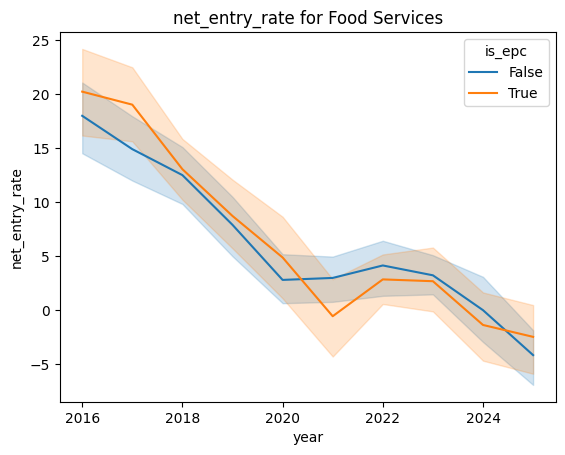

In [205]:
sns.lineplot(
    open_close_tracts_gdf,
    x='year',
    y='net_entry_rate',
    hue='is_epc'
)

plt.title(f'{'net_entry_rate'} for {naics_name}')
